# Nigeria Weather ETL Analysis

## Project Overview

This project demonstrates the development of an ETL (Extract, Transform, Load) pipeline for collecting and analysing current weather data across Nigeria.

Weather data was collected from the OpenWeather API for the 36 states of Nigeria and the Federal Capital Territory (FCT). The extracted data was then transformed and structured using Python and Pandas before being analysed to identify differences in weather conditions across states and Nigeria's six geopolitical zones.

## Project Objectives

The main objectives of this project are to:

- Extract weather data from the OpenWeather API.
- Transform and structure the extracted data using Pandas.
- Map each Nigerian state to its respective geopolitical zone.
- Validate and clean the transformed dataset.
- Analyse temperature, humidity, wind speed and other weather variables.
- Compare weather conditions across Nigerian states and geopolitical zones.
- Generate insights from the transformed dataset.
- Save the processed data for further use.

## Data Source

The data used in this project was obtained through the OpenWeather API.

The analysis covers:

- 36 Nigerian states
- Federal Capital Territory (FCT)
- 6 geopolitical zones

## Tools and Technologies

The following tools and technologies were used:

- Python
- Pandas
- Requests
- OpenWeather API
- Jupyter Notebook
- GitHub

## ETL Workflow

The project follows three main stages:

**Extract:** Weather data is retrieved from the OpenWeather API.

**Transform:** The extracted API responses are converted into a structured DataFrame, validated, and mapped to Nigeria's geopolitical zones.

**Load:** The processed dataset is saved as a CSV file for storage and further analysis.

## Analysis Focus

The analysis focuses on questions such as:

- Which geopolitical zone has the highest average temperature?
- Which geopolitical zone has the highest average humidity?
- Which states have the highest and lowest temperatures?
- Which states record the highest wind speeds?
- Which geopolitical zones show the greatest temperature variation?

The results are presented using tables, statistical summaries and visualisations.

# Import the required library

In [1]:
pip install requests pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\SAMSUNG\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

Store your API key safely

Since you're going to upload this project to GitHub, do not write this:

API_KEY = "your_actual_api_key"

Instead, we'll use an environment variable.

In [3]:
import os

os.environ["OPENWEATHER_API_KEY"] = "6518cc1b6508c85bd2a8d7b3eb4fc094"

# Test the API

In [4]:
import os
import requests

API_KEY = os.environ["OPENWEATHER_API_KEY"]

city = "Lagos"

url = "https://api.openweathermap.org/data/2.5/weather"

params = {
    "q": city,
    "appid": API_KEY,
    "units": "metric"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

if response.status_code == 200:
    print("API connection successful!")
    print(response.json())
else:
    print(response.json())

Status code: 200
API connection successful!
{'coord': {'lon': 3.75, 'lat': 6.5833}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 29.9, 'feels_like': 33.67, 'temp_min': 29.9, 'temp_max': 29.9, 'pressure': 1011, 'humidity': 65, 'sea_level': 1011, 'grnd_level': 1011}, 'visibility': 10000, 'wind': {'speed': 4.46, 'deg': 222, 'gust': 5.23}, 'clouds': {'all': 76}, 'dt': 1787752133, 'sys': {'country': 'NG', 'sunrise': 1787722729, 'sunset': 1787766922}, 'timezone': 3600, 'id': 2332453, 'name': 'Lagos', 'cod': 200}


# Extracting Data for Cities

In [5]:
locations = [

    # NORTH CENTRAL
    ("Benue", "Makurdi", "North Central"),
    ("Kogi", "Lokoja", "North Central"),
    ("Kwara", "Ilorin", "North Central"),
    ("Nasarawa", "Lafia", "North Central"),
    ("Niger", "Minna", "North Central"),
    ("Plateau", "Jos", "North Central"),
    ("FCT", "Abuja", "North Central"),

    # NORTH EAST
    ("Adamawa", "Yola", "North East"),
    ("Bauchi", "Bauchi", "North East"),
    ("Borno", "Maiduguri", "North East"),
    ("Gombe", "Gombe", "North East"),
    ("Taraba", "Jalingo", "North East"),
    ("Yobe", "Damaturu", "North East"),

    # NORTH WEST
    ("Jigawa", "Dutse", "North West"),
    ("Kaduna", "Kaduna", "North West"),
    ("Kano", "Kano", "North West"),
    ("Katsina", "Katsina", "North West"),
    ("Kebbi", "Birnin Kebbi", "North West"),
    ("Sokoto", "Sokoto", "North West"),
    ("Zamfara", "Gusau", "North West"),

    # SOUTH EAST
    ("Abia", "Umuahia", "South East"),
    ("Anambra", "Awka", "South East"),
    ("Ebonyi", "Abakaliki", "South East"),
    ("Enugu", "Enugu", "South East"),
    ("Imo", "Owerri", "South East"),

    # SOUTH SOUTH
    ("Akwa Ibom", "Uyo", "South South"),
    ("Bayelsa", "Yenagoa", "South South"),
    ("Cross River", "Calabar", "South South"),
    ("Delta", "Asaba", "South South"),
    ("Edo", "Benin City", "South South"),
    ("Rivers", "Port Harcourt", "South South"),

    # SOUTH WEST
    ("Ekiti", "Ado-Ekiti", "South West"),
    ("Lagos", "Ikeja", "South West"),
    ("Ogun", "Abeokuta", "South West"),
    ("Ondo", "Akure", "South West"),
    ("Osun", "Osogbo", "South West"),
    ("Oyo", "Ibadan", "South West")
]

print("Number of locations:", len(locations))

Number of locations: 37


# DATA TRANSFORMATION: Creating a structured table

In [6]:
weather_data = []

for state, city, zone in locations:

    params = {
        "q": f"{city},NG",
        "appid": API_KEY,
        "units": "metric"
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:

        data = response.json()

        weather_data.append({
            "State": state,
            "City": city,
            "Geopolitical_Zone": zone,
            "Temperature_C": data["main"]["temp"],
            "Feels_Like_C": data["main"]["feels_like"],
            "Humidity_%": data["main"]["humidity"],
            "Pressure_hPa": data["main"]["pressure"],
            "Wind_Speed_mps": data["wind"]["speed"],
            "Weather": data["weather"][0]["description"]
        })

        print(f"{state}: data extracted successfully")

    else:
        print(f"{state}: failed - status code {response.status_code}")


Benue: data extracted successfully
Kogi: data extracted successfully
Kwara: data extracted successfully
Nasarawa: data extracted successfully
Niger: data extracted successfully
Plateau: data extracted successfully
FCT: data extracted successfully
Adamawa: data extracted successfully
Bauchi: data extracted successfully
Borno: data extracted successfully
Gombe: data extracted successfully
Taraba: data extracted successfully
Yobe: data extracted successfully
Jigawa: data extracted successfully
Kaduna: data extracted successfully
Kano: data extracted successfully
Katsina: data extracted successfully
Kebbi: data extracted successfully
Sokoto: data extracted successfully
Zamfara: data extracted successfully
Abia: data extracted successfully
Anambra: data extracted successfully
Ebonyi: data extracted successfully
Enugu: data extracted successfully
Imo: data extracted successfully
Akwa Ibom: data extracted successfully
Bayelsa: data extracted successfully
Cross River: data extracted successful

In [7]:
weather_df = pd.DataFrame(weather_data)

# Data Validation

In [8]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              37 non-null     str    
 1   City               37 non-null     str    
 2   Geopolitical_Zone  37 non-null     str    
 3   Temperature_C      37 non-null     float64
 4   Feels_Like_C       37 non-null     float64
 5   Humidity_%         37 non-null     int64  
 6   Pressure_hPa       37 non-null     int64  
 7   Wind_Speed_mps     37 non-null     float64
 8   Weather            37 non-null     str    
dtypes: float64(3), int64(2), str(4)
memory usage: 2.7 KB


In [9]:
weather_df.isnull().sum()

State                0
City                 0
Geopolitical_Zone    0
Temperature_C        0
Feels_Like_C         0
Humidity_%           0
Pressure_hPa         0
Wind_Speed_mps       0
Weather              0
dtype: int64

In [10]:
weather_df.describe()

,Temperature_C,Feels_Like_C,Humidity_%,Pressure_hPa,Wind_Speed_mps
count,37.000000,37.000000,37.000000,37.000000,37.000000
mean,31.136216,34.351892,61.486486,1009.216216,2.921892
std,3.800762,3.396117,19.770379,1.356776,1.075084
min,26.510000,26.510000,25.000000,1006.000000,0.720000
25%,28.260000,31.680000,41.000000,1008.000000,2.300000
50%,29.740000,34.110000,69.000000,1010.000000,2.780000
75%,34.890000,37.120000,78.000000,1010.000000,3.740000
max,39.100000,39.690000,88.000000,1011.000000,5.710000


In [11]:
weather_df.columns

Index(['State', 'City', 'Geopolitical_Zone', 'Temperature_C', 'Feels_Like_C',
       'Humidity_%', 'Pressure_hPa', 'Wind_Speed_mps', 'Weather'],
      dtype='str')

In [12]:
weather_df["Geopolitical_Zone"].value_counts()

Geopolitical_Zone
North Central    7
North West       7
North East       6
South South      6
South West       6
South East       5
Name: count, dtype: int64

# Load the Transformed Data

In [13]:
weather_df.to_csv("weather_data.csv", index=False)

print("Weather dataset saved successfully!")

Weather dataset saved successfully!


# Sorting data 

In [14]:
zone_order = [
    "North Central",
    "North East",
    "North West",
    "South East",
    "South South",
    "South West"
]

weather_df["Geopolitical_Zone"] = pd.Categorical(
    weather_df["Geopolitical_Zone"],
    categories=zone_order,
    ordered=True
)

weather_df = weather_df.sort_values(
    ["Geopolitical_Zone", "State"]
).reset_index(drop=True)

weather_df

,State,City,Geopolitical_Zone,Temperature_C,Feels_Like_C,Humidity_%,Pressure_hPa,Wind_Speed_mps,Weather
0,Benue,Makurdi,North Central,31.48,37.03,64,1009,2.30,overcast clouds
1,FCT,Abuja,North Central,28.41,31.33,69,1010,1.12,overcast clouds
2,Kogi,Lokoja,North Central,31.57,37.25,64,1009,2.47,broken clouds
3,Kwara,Ilorin,North Central,28.41,32.12,74,1010,2.18,overcast clouds
4,Nasarawa,Lafia,North Central,29.80,35.76,75,1009,2.79,scattered clouds
5,Niger,Minna,North Central,30.37,34.70,65,1010,1.64,overcast clouds
6,Plateau,Jos,North Central,28.37,28.88,50,1010,4.06,few clouds
7,Adamawa,Yola,North East,35.67,39.18,42,1007,0.72,scattered clouds
8,Bauchi,Bauchi,North East,35.36,36.16,34,1008,4.15,broken clouds
9,Borno,Maiduguri,North East,39.10,39.61,25,1006,4.57,few clouds


# BUSINESS QUESTIONS

1. Which geopolitical zone has the highest average temperature?

In [15]:
zone_temperature = (
    weather_df.groupby("Geopolitical_Zone")["Temperature_C"]
    .mean()
    .sort_values(ascending=False)
)

zone_temperature

Geopolitical_Zone
North East       36.030000
North West       35.437143
North Central    29.772857
South East       28.382000
South West       28.323333
South South      27.923333
Name: Temperature_C, dtype: float64

2. Average Humidity by Zones

In [16]:
zone_humidity = (
    weather_df.groupby("Geopolitical_Zone")["Humidity_%"]
    .mean()
    .sort_values(ascending=False)
)

zone_humidity.round(2)

Geopolitical_Zone
South South      79.50
South East       77.40
South West       76.67
North Central    65.86
North West       37.86
North East       37.50
Name: Humidity_%, dtype: float64

3. Which states have the highest and lowest temperatures?

In [17]:
state_temperature = (
    weather_df[["State", "Geopolitical_Zone", "Temperature_C"]]
    .sort_values("Temperature_C", ascending=False)
)

state_temperature.head(10)

,State,Geopolitical_Zone,Temperature_C
9,Borno,North East,39.10
12,Yobe,North East,38.76
16,Katsina,North West,36.95
18,Sokoto,North West,36.81
15,Kano,North West,36.44
13,Jigawa,North West,36.09
17,Kebbi,North West,35.81
7,Adamawa,North East,35.67
8,Bauchi,North East,35.36
19,Zamfara,North West,34.89


--- Lowest Temperature---

In [18]:
state_temperature.tail(10)

,State,Geopolitical_Zone,Temperature_C
23,Enugu,South East,28.26
36,Oyo,South West,27.93
25,Akwa Ibom,South South,27.89
26,Bayelsa,South South,27.88
24,Imo,South East,27.76
35,Osun,South West,27.73
20,Abia,South East,27.66
31,Ekiti,South West,27.11
34,Ondo,South West,26.89
29,Edo,South South,26.51


In [19]:
hottest_state = state_temperature.iloc[0]

coolest_state = state_temperature.iloc[-1]

print(
    f"Hottest: {hottest_state['State']} "
    f"({hottest_state['Temperature_C']:.2f}°C)"
)

print(
    f"Coolest: {coolest_state['State']} "
    f"({coolest_state['Temperature_C']:.2f}°C)"
)

Hottest: Borno (39.10°C)
Coolest: Edo (26.51°C)


4. Which states have the highest wind speeds?

In [20]:
state_wind = (
    weather_df[["State", "Geopolitical_Zone", "Wind_Speed_mps"]]
    .sort_values("Wind_Speed_mps", ascending=False)
)

state_wind.head(10)

,State,Geopolitical_Zone,Wind_Speed_mps
12,Yobe,North East,5.71
30,Rivers,South South,4.69
9,Borno,North East,4.57
22,Ebonyi,South East,4.17
8,Bauchi,North East,4.15
32,Lagos,South West,4.12
6,Plateau,North Central,4.06
20,Abia,South East,3.81
26,Bayelsa,South South,3.81
25,Akwa Ibom,South South,3.74


5. Which states have the highest combination of heat and humidity?

In [21]:
heat_humidity = (
    weather_df[[
        "State",
        "Geopolitical_Zone",
        "Temperature_C",
        "Humidity_%"
    ]]
    .copy()
)

heat_humidity["Heat_Humidity_Score"] = (
    heat_humidity["Temperature_C"] * heat_humidity["Humidity_%"]
)

heat_humidity = heat_humidity.sort_values(
    "Heat_Humidity_Score",
    ascending=False
)

heat_humidity.head(10)

,State,Geopolitical_Zone,Temperature_C,Humidity_%,Heat_Humidity_Score
29,Edo,South South,26.51,88,2332.88
28,Delta,South South,28.33,81,2294.73
4,Nasarawa,North Central,29.80,75,2235.00
34,Ondo,South West,26.89,83,2231.87
21,Anambra,South East,28.49,78,2222.22
24,Imo,South East,27.76,80,2220.80
27,Cross River,South South,28.33,78,2209.74
36,Oyo,South West,27.93,79,2206.47
23,Enugu,South East,28.26,78,2204.28
25,Akwa Ibom,South South,27.89,79,2203.31


6. Geopolitical Zones that Show the Greatest Weather Variation

In [22]:
zone_temperature_range = (
    weather_df.groupby("Geopolitical_Zone")["Temperature_C"]
    .agg(["min", "max", "mean"])
)

zone_temperature_range["Temperature_Range"] = (
    zone_temperature_range["max"] - zone_temperature_range["min"]
)

zone_temperature_range.sort_values(
    "Temperature_Range",
    ascending=False
).round(2)

,min,max,mean,Temperature_Range
Geopolitical_Zone,,,,
North East,32.44,39.10,36.03,6.66
North West,31.07,36.95,35.44,5.88
South West,26.89,30.94,28.32,4.05
North Central,28.37,31.57,29.77,3.20
South South,26.51,28.60,27.92,2.09
South East,27.66,29.74,28.38,2.08


In [23]:
most_variable_zone = zone_temperature_range["Temperature_Range"].idxmax()
largest_range = zone_temperature_range["Temperature_Range"].max()

print(
    f"{most_variable_zone} has the greatest temperature variation "
    f"with a range of {largest_range:.2f}°C."
)

North East has the greatest temperature variation with a range of 6.66°C.


# DATA VISUALIZATION

1. AVERAGE TEMPERATURE BY GEOPOLITICAL ZONES

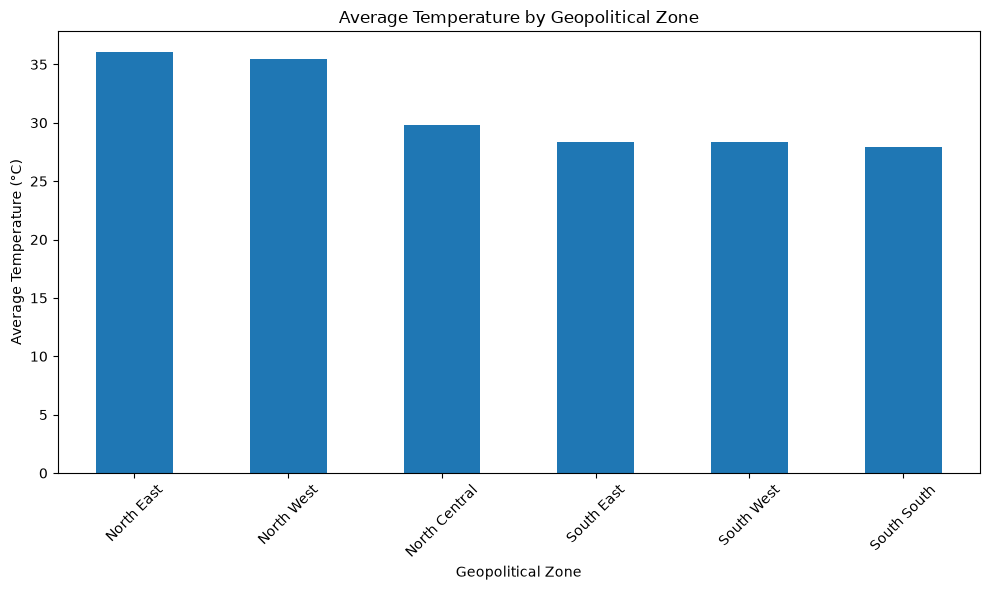

In [26]:
import matplotlib.pyplot as plt

zone_temperature = (
    weather_df.groupby("Geopolitical_Zone")["Temperature_C"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

zone_temperature.plot(kind="bar")

plt.title("Average Temperature by Geopolitical Zone")
plt.xlabel("Geopolitical Zone")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

2. AVERAGE HUMIDITY BY GEOPOLITICAL ZONES

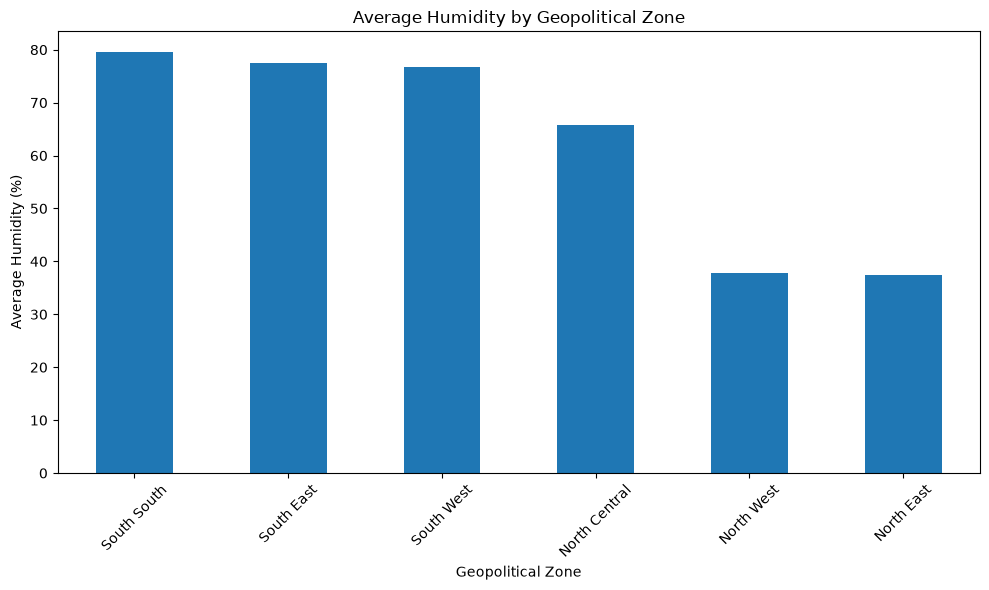

In [27]:
zone_humidity = (
    weather_df.groupby("Geopolitical_Zone")["Humidity_%"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

zone_humidity.plot(kind="bar")

plt.title("Average Humidity by Geopolitical Zone")
plt.xlabel("Geopolitical Zone")
plt.ylabel("Average Humidity (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

3. TOP 10 STATES BY TEMPERATURE

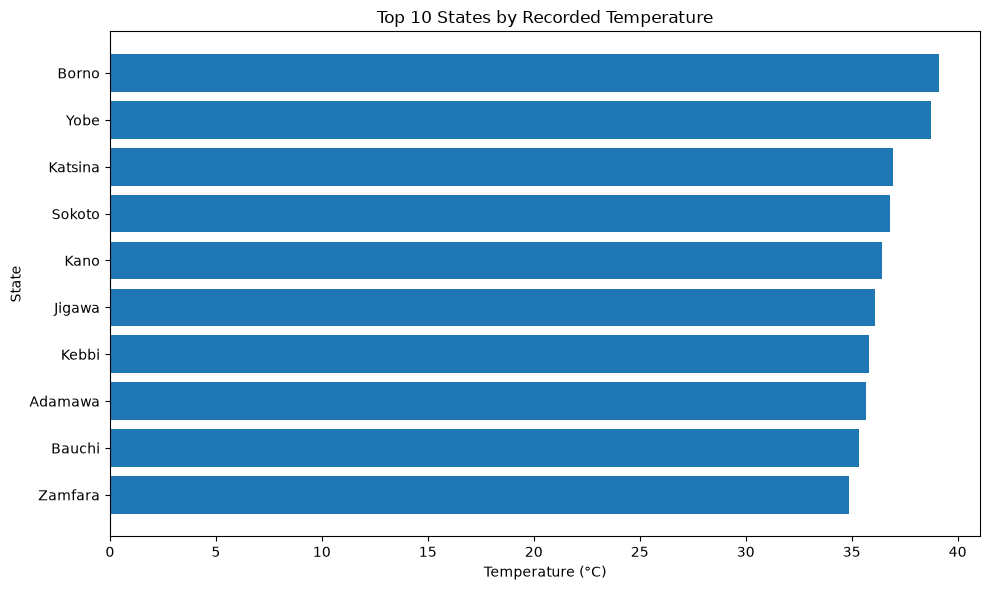

In [28]:
top_10_temperature = (
    weather_df[
        ["State", "Temperature_C"]
    ]
    .sort_values("Temperature_C", ascending=False)
    .head(10)
    .sort_values("Temperature_C")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_temperature["State"],
    top_10_temperature["Temperature_C"]
)

plt.title("Top 10 States by Recorded Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("State")
plt.tight_layout()

plt.show()

# Creating a Python ETL Pipeline

In [24]:
%%writefile weather_etl.py
import os
import requests
import pandas as pd
import time


# ============================================================
# 1. EXTRACT
# ============================================================

API_KEY = os.getenv("OPENWEATHER_API_KEY")

if not API_KEY:
    raise ValueError(
        "OPENWEATHER_API_KEY was not found. "
        "Please set your API key as an environment variable."
    )


# One representative city for each Nigerian state + FCT
locations = [
    # North Central
    ("Benue", "Makurdi", "North Central"),
    ("Kogi", "Lokoja", "North Central"),
    ("Kwara", "Ilorin", "North Central"),
    ("Nasarawa", "Lafia", "North Central"),
    ("Niger", "Minna", "North Central"),
    ("Plateau", "Jos", "North Central"),
    ("FCT", "Abuja", "North Central"),

    # North East
    ("Adamawa", "Yola", "North East"),
    ("Bauchi", "Bauchi", "North East"),
    ("Borno", "Maiduguri", "North East"),
    ("Gombe", "Gombe", "North East"),
    ("Taraba", "Jalingo", "North East"),
    ("Yobe", "Damaturu", "North East"),

    # North West
    ("Jigawa", "Dutse", "North West"),
    ("Kaduna", "Kaduna", "North West"),
    ("Kano", "Kano", "North West"),
    ("Katsina", "Katsina", "North West"),
    ("Kebbi", "Birnin Kebbi", "North West"),
    ("Sokoto", "Sokoto", "North West"),
    ("Zamfara", "Gusau", "North West"),

    # South East
    ("Abia", "Umuahia", "South East"),
    ("Anambra", "Awka", "South East"),
    ("Ebonyi", "Abakaliki", "South East"),
    ("Enugu", "Enugu", "South East"),
    ("Imo", "Owerri", "South East"),

    # South South
    ("Akwa Ibom", "Uyo", "South South"),
    ("Bayelsa", "Yenagoa", "South South"),
    ("Cross River", "Calabar", "South South"),
    ("Delta", "Asaba", "South South"),
    ("Edo", "Benin City", "South South"),
    ("Rivers", "Port Harcourt", "South South"),

    # South West
    ("Ekiti", "Ado-Ekiti", "South West"),
    ("Lagos", "Ikeja", "South West"),
    ("Ogun", "Abeokuta", "South West"),
    ("Ondo", "Akure", "South West"),
    ("Osun", "Osogbo", "South West"),
    ("Oyo", "Ibadan", "South West")
]


weather_data = []


for state, city, zone in locations:

    url = "https://api.openweathermap.org/data/2.5/weather"

    params = {
        "q": f"{city},NG",
        "appid": API_KEY,
        "units": "metric"
    }

    try:
        response = requests.get(url, params=params, timeout=10)

        if response.status_code == 200:

            data = response.json()

            weather_data.append({
                "City": city,
                "State": state,
                "Country": "Nigeria",
                "Geopolitical_Zone": zone,
                "Temperature_C": data["main"]["temp"],
                "Feels_Like_C": data["main"]["feels_like"],
                "Humidity_%": data["main"]["humidity"],
                "Pressure_hPa": data["main"]["pressure"],
                "Wind_Speed_mps": data["wind"]["speed"],
                "Weather": data["weather"][0]["description"]
            })

            print(f"{state}: data extracted successfully")

        else:
            print(
                f"{state}: extraction failed "
                f"(Status code: {response.status_code})"
            )

    except requests.exceptions.RequestException as error:
        print(f"{state}: request failed - {error}")

    # Prevent sending requests too quickly
    time.sleep(1)


# ============================================================
# 2. TRANSFORM
# ============================================================

weather_df = pd.DataFrame(weather_data)

print("\nData extracted:")
print(weather_df.head())


# Check for missing values
print("\nMissing values:")
print(weather_df.isnull().sum())


# Remove duplicate records if any
weather_df = weather_df.drop_duplicates()


# Sort by geopolitical zone and state
weather_df = weather_df.sort_values(
    ["Geopolitical_Zone", "State"]
).reset_index(drop=True)


print("\nFinal dataset:")
print(weather_df)


# ============================================================
# 3. LOAD
# ============================================================

weather_df.to_csv(
    "weather_data.csv",
    index=False
)

print("\nProcessed dataset saved successfully as weather_data.csv")

print("\nFinal dataset shape:")
print(weather_df.shape)

print("\nETL pipeline completed successfully.")

Overwriting weather_etl.py


In [25]:
!python weather_etl.py

Benue: data extracted successfully
Kogi: data extracted successfully
Kwara: data extracted successfully
Nasarawa: data extracted successfully
Niger: data extracted successfully
Plateau: data extracted successfully
FCT: data extracted successfully
Adamawa: data extracted successfully
Bauchi: data extracted successfully
Borno: data extracted successfully
Gombe: data extracted successfully
Taraba: data extracted successfully
Yobe: data extracted successfully
Jigawa: data extracted successfully
Kaduna: data extracted successfully
Kano: data extracted successfully
Katsina: data extracted successfully
Kebbi: data extracted successfully
Sokoto: data extracted successfully
Zamfara: data extracted successfully
Abia: data extracted successfully
Anambra: data extracted successfully
Ebonyi: data extracted successfully
Enugu: data extracted successfully
Imo: data extracted successfully
Akwa Ibom: data extracted successfully
Bayelsa: data extracted successfully
Cross River: data extracted successful